# Exercise 1 Overview

In this exercise you will implement basic functions to compute the forward kinematics of arbitrary robot arms using the Denavit-Hardenberg notations. We will utilize MuJoCo as a simulation framework to visualize your results.

For submission we expect you to submit a zip file including the following files:
- (1) A pdf version of this jupyter notebook (you can use the print or export function)
- (2) The Jupyter notebook itself as ipynb file
- (3) Any videos produced

For a valid submission, please fill in the two fields below:


In [77]:
your_name = "Nicolau Vilaclara"
your_vu_id = "liw899"

## Setup
First we download some files for using mujco:

In [78]:
#not on linux atm
#grabs wsl instead of git bash, so same clone logic but in python
import os, subprocess

if not os.path.isdir("mujoco_menagerie"):
    print("Cloning mujoco_menagerie...")
    subprocess.run(["git", "clone", "https://github.com/google-deepmind/mujoco_menagerie.git"])
else:
    print("mujoco_menagerie already exists. Skipping clone.")


mujoco_menagerie already exists. Skipping clone.


In [79]:
import distutils.util
import os
import subprocess
import mediapy as media

if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU.')
# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
#%env MUJOCO_GL=egl linux only and mujoco on windows uses wgl by default

try:
  print('Checking that the installation succeeded:')
  import mujoco
  from mujoco import minimize
  from mujoco import rollout
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.')
print('MuJoCo installation successful.')

from IPython.display import clear_output
clear_output()

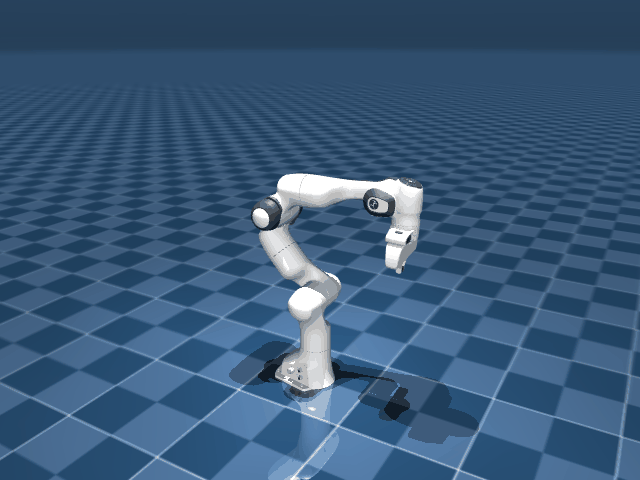

In [80]:
## Run now a basic test to see if we can use Mujoco
import mujoco
import mediapy as media
import numpy as np
from PIL import Image
import io
from IPython.display import display, Image as IPImage

# 1. Load the Franka Emika Panda model from the cloned menagerie repository
model_path = "mujoco_menagerie/franka_emika_panda/scene.xml"
model = mujoco.MjModel.from_xml_path(model_path)
data = mujoco.MjData(model)

# 2. Set up the headless renderer and a list to store video frames
renderer = mujoco.Renderer(model, height=480, width=640)
frames = []

# Optional: Enable contact force visualization (helps debug interactions)
options = mujoco.MjvOption()
mujoco.mjv_defaultOption(options)

# 3. Setup simulation parameters for a 3-second 30fps video
duration = 3.0  # seconds
framerate = 30
# Calculate how many MuJoCo physics steps fit into one video frame
steps_per_frame = int(1.0 / (framerate * model.opt.timestep))

# Reset physics state to ensure a clean start
mujoco.mj_resetData(model, data)

# 4. Set the robot to a comfortable "home" position
# The Franka has 7 joints + 2 gripper joints
data.qpos[:7] = [0, -0.785, 0, -2.356, 0, 1.571, 0.785]

# 5. Run the simulation loop
for frame_idx in range(int(duration * framerate)):
    # Step the physics engine forward
    for _ in range(steps_per_frame):
        # Apply a simple sine wave motion to the first joint (base rotation)
        # This will make the robot slowly sweep side to side
        data.ctrl[0] = np.sin(data.time * 2.0) * 1.5 
        mujoco.mj_step(model, data)
        
    # Update camera and render the scene
    renderer.update_scene(data, scene_option=options)
    frames.append(renderer.render())

#note: added this, if the renderer is left open and the cell is rerun the new one renders all black
renderer.close()

# 6. Display the resulting video inside the Jupyter notebook cell
# media.show_video(frames, fps=framerate)
pil_images = [Image.fromarray(frame) for frame in frames]
    
# Save frames into an in-memory byte buffer as an animated GIF
buffer = io.BytesIO()
pil_images[0].save(
    buffer,
    format='GIF',
    save_all=True,
    append_images=pil_images[1:],
    duration=int(500 / framerate), # duration per frame in milliseconds
    loop=0
)
buffer.seek(0)

# Display the GIF inside the Jupyter notebook
display(IPImage(data=buffer.read(), format='gif'))

# Task 1: Forward Kinematics with Denavit-Hartenberg (DH) 

In this exercise, you will build a general-purpose Forward Kinematics (FK) engine from first principles using Python and NumPy. Your implementation will construct $4 \times 4$ homogeneous transformation matrices using the **Standard Denavit-Hartenberg (SDH)** convention.

To make the exercise easier we will only implement forward and inverse kinematics for reaching positions in this exercise.

---

### Mathematical Background

The Standard DH convention describes the transformation from frame $i-1$ to frame $i$ using four parameters:
* $\theta_i$: Joint angle around the $Z_{i-1}$ axis.
* $d_i$: Joint offset along the $Z_{i-1}$ axis.
* $a_i$: Link length along the $X_i$ axis.
* $\alpha_i$: Link twist around the $X_i$ axis.

The homogeneous transformation matrix $T_i^{i-1}$ is formed by multiplying four elementary transformations:

$$T_i^{i-1} = Rot_z(\theta_i) \cdot Trans_z(d_i) \cdot Trans_x(a_i) \cdot Rot_x(\alpha_i)$$

When expanded, the single-link transformation matrix becomes:

$$T_i^{i-1} = \begin{bmatrix} 
\cos\theta_i & -\sin\theta_i \cos\alpha_i & \sin\theta_i \sin\alpha_i & a_i \cos\theta_i \\ 
\sin\theta_i & \cos\theta_i \cos\alpha_i & -\cos\theta_i \sin\alpha_i & a_i \sin\theta_i \\ 
0 & \sin\alpha_i & \cos\alpha_i & d_i \\ 
0 & 0 & 0 & 1 
\end{bmatrix}$$

---

### Handling Revolute vs. Prismatic Joints

To make our engine reusable for any robot, we must handle both **Revolute ('R')** (rotational) and **Prismatic ('P')** (translational) joints:

1. **Static DH Table:** Contains offset values $[\theta_{\text{offset}}, d_{\text{offset}}, a, \alpha]$.
2. **Joint Types:** A list indicating the variable type for each link (e.g., `['R', 'R', 'R', 'R', 'R', 'R', 'R']`).
3. **Dynamic Configuration Vector ($q$):** The live state of the robot joints $[q_1, q_2, \dots, q_N]$.

For link $i$ at state $q_i$:
* If joint $i$ is **Revolute ('R')**: $\theta_i = \theta_{\text{offset}, i} + q_i$ and $d_i = d_{\text{offset}, i}$
* If joint $i$ is **Prismatic ('P')**: $\theta_i = \theta_{\text{offset}, i}$ and $d_i = d_{\text{offset}, i} + q_i$

### Python Tip
You will need to perform multiple matrix multiplications! Consider the following functionality in Python:
https://peps.python.org/pep-0465/
This is also applicable to numpy matrices.

---

### Your Tasks

#### Task 1.1: Elementary Transformations
Implement basic functions that return $4 \times 4$ homogeneous matrices for elementary rotations and translations:
* `rot_z(angle)`: Rotation around $Z$-axis by `angle` radians.
* `trans_z(distance)`: Translation along $Z$-axis by `distance` meters.
* `trans_x(distance)`: Translation along $X$-axis by `distance` meters.
* `rot_x(angle)`: Rotation around $X$-axis by `angle` radians.

#### Task 1.2: Single DH Link Matrix
Implement `dh_transform_single(theta, d, a, alpha)`:
* Takes the 4 scalar DH parameters for a single link.
* Combines the elementary transformations to return the $4 \times 4$ matrix $T_i^{i-1}$.

#### Task 1.3: Full Chain Forward Kinematics
Implement `forward_kinematics(q, dh_table, joint_types)`:
* **`q`**: A list or array of joint variables $[q_1, q_2, \dots, q_N]$.
* **`dh_table`**: An $N \times 4$ matrix containing rows of $[\theta_{\text{offset}}, d_{\text{offset}}, a, \alpha]$.
* **`joint_types`**: A list of strings of length $N$, e.g., `['R', 'R', 'P', ...]`.
* **Returns**: 
    1. `T_total`: The $4 \times 4$ transform from the base to the end-effector ($T_N^0 = T_1^0 \cdot T_2^1 \cdots T_N^{N-1}$).
    2. `all_transforms`: A list of intermediate cumulative matrices $[T_1^0, T_2^0, \dots, T_N^0]$.

## Task 1.1 Code - 2 Points
Please make sure that each function returns a matrix (np.array)! 

In [81]:
import numpy as np


def rot_z(angle: float) -> np.ndarray:
    """Calculates 4x4 Homogeneous Rotation Matrix around Z-axis."""
    c, s = np.cos(angle), np.sin(angle)
    return np.array([
        [c, -s, 0, 0],
        [s,  c, 0, 0],
        [0,  0, 1, 0],
        [0,  0, 0, 1],
    ])


def trans_z(distance: float) -> np.ndarray:
    """Calculates 4x4 Homogeneous Translation Matrix along Z-axis."""
    T = np.eye(4)
    T[2, 3] = distance
    return T


def trans_x(distance: float) -> np.ndarray:
    """Calculates 4x4 Homogeneous Translation Matrix along X-axis."""
    T = np.eye(4)
    T[0, 3] = distance
    return T


def rot_x(angle: float) -> np.ndarray:
    """Calculates 4x4 Homogeneous Rotation Matrix around X-axis."""
    c, s = np.cos(angle), np.sin(angle)
    return np.array([
        [1, 0,  0, 0],
        [0, c, -s, 0],
        [0, s,  c, 0],
        [0, 0,  0, 1],
    ])


## Task 1.2 Code - 1 Point
Add here your code for Task 1.2.
Again make sure the output is a numpy array (np.array)

In [82]:
def dh_transform_single(
    theta: float, d: float, a: float, alpha: float
) -> np.ndarray:
    """Calculates the 4x4 Standard DH matrix for a single link using elementary transformations.

    T_i^{i-1} = rot_z(theta) @ trans_z(d) @ trans_x(a) @ rot_x(alpha)
    """
    return rot_z(theta) @ trans_z(d) @ trans_x(a) @ rot_x(alpha)


### Task 1.3 Code - 3 Points
Implement now the full DH algorithm using the functions you implemented above.

In [83]:
def forward_kinematics(q, dh_table, joint_types):
    """Calculates forward kinematics for a serial chain robot.

    Parameters:
    - q (array-like): Joint vector of length N
    - dh_table (np.ndarray): N x 4 array of [theta_offset, d_offset, a, alpha]
    - joint_types (list): List of strings ('R' for revolute, 'P' for prismatic)

    Returns:
    - T_total (np.ndarray): 4x4 matrix from base frame 0 to frame N
    - all_transforms (list): List of 4x4 matrices [T_1_0, T_2_0, ..., T_N_0]
    """
    T_current = np.eye(4)
    all_transforms = []

    for i in range(len(q)):

        theta, d, a, alpha = dh_table[i]

        #joint var goes into theta for R, into d for P
        if joint_types[i] == 'R':
            theta = theta + q[i]
        elif joint_types[i] == 'P':
            d = d + q[i]
        else:
            raise ValueError(f"unknown joint type {joint_types[i]}")

        T_current = T_current @ dh_transform_single(theta, d, a, alpha)

        all_transforms.append(T_current.copy())
        

    return T_current, all_transforms


## Task 1.4 - 1 Point
Now we will evaluate your functions. If correct, it will compute the positions of the joints of the Franka robot and reach the desired goal locations. For convenience, we will compare the simulated MuJoCo positions of the endeffector with the ones your DH algorithm computes.

--- Kinematics Evaluation Summary ---

✅ Pose 1: PASSED
[0.088 0.    0.926]


""

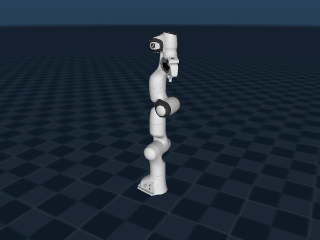

--------------------------------------------------
✅ Pose 2: PASSED
[0.3069 0.     0.5903]


""

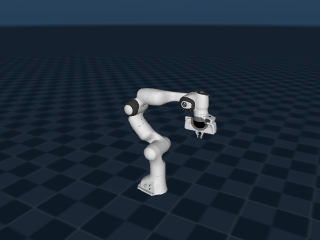

--------------------------------------------------
✅ Pose 3: PASSED
[ 0.362  -0.4446  0.807 ]


""

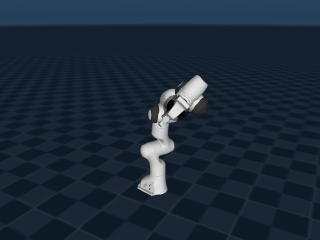

--------------------------------------------------
✅ Pose 4: PASSED
[ 0.3416 -0.2038  0.255 ]


""

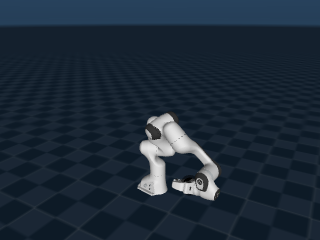

--------------------------------------------------

Final Score: 4/4 Poses Matched.



In [84]:
import mujoco
import numpy as np
import mediapy as media

def validate_and_visualize_fk():
    # 1. Load the MuJoCo model
    model_path = "mujoco_menagerie/franka_emika_panda/scene.xml"
    try:
        model = mujoco.MjModel.from_xml_path(model_path)
        data = mujoco.MjData(model)
    except Exception as e:
        print(f"Failed to load MuJoCo model: {e}")
        return

    # 2. DH Parameters
    franka_dh = np.array([
        [0.0, 0.333, 0.0, -np.pi / 2],
        [0.0, 0.0, 0.0, np.pi / 2],
        [0.0, 0.316, 0.0825, np.pi / 2],
        [0.0, 0.0, -0.0825, -np.pi / 2],
        [0.0, 0.384, 0.0, np.pi / 2],
        [0.0, 0.0, 0.088, np.pi / 2],
        [0.0, 0.107, 0.0, 0.0],
    ])
    joint_types = ['R'] * 7

    # Distinct static poses to test
    test_cases = [
        np.zeros(7),
        np.array([0.0, -np.pi/4, 0.0, -3*np.pi/4, 0.0, np.pi/2, -np.pi/4]),
        np.array([-0.5, 0.2, -0.3, -1.0, -0.8, 1.5, -0.7]),
        np.array([-1.2, 0.5, 0.8, -2.1, -0.4, 0.9, 1.2,])
    ]

    link8_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "hand")
    link7_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "link7")

    # 3. Evaluation and Image Generation
    print("--- Kinematics Evaluation Summary ---\n")
    passed = 0
    failed = 0

    # Initialize renderer once
    with mujoco.Renderer(model) as renderer:
        
        for i, q_test in enumerate(test_cases):
            # Update MuJoCo to the target pose
            data.qpos[:7] = q_test[:7]
            mujoco.mj_kinematics(model, data)
            mujoco_pos = data.xpos[link8_id].copy()

            # Calculate DH position
            T_flange, _ = forward_kinematics(q_test, franka_dh, joint_types)
            dh_pos = T_flange[:3, 3]

            # Verify the math
            if np.allclose(dh_pos, mujoco_pos, atol=1e-4):
                passed += 1
                print(f"✅ Pose {i+1}: PASSED")
            else:
                failed += 1
                print(f"❌ Pose {i+1}: FAILED")
                print(f"   DH Pos:     {np.round(dh_pos, 4)}")
                print(f"   MuJoCo Pos: {np.round(mujoco_pos, 4)}")
            print(np.round(mujoco_pos, 4))

            # Update the visual scene with the new robot position
            renderer.update_scene(data)

            # --- ADD RED SPHERE (MuJoCo Ground Truth) ---
            if renderer.scene.ngeom < renderer.scene.maxgeom:
                geom = renderer.scene.geoms[renderer.scene.ngeom]
                mujoco.mjv_initGeom(
                    geom,
                    mujoco.mjtGeom.mjGEOM_SPHERE,
                    np.array([0.06, 0.0, 0.0]),                      # 6cm radius
                    mujoco_pos,                                      # MuJoCo Position
                    np.eye(3).flatten(),                             
                    np.array([1.0, 0.0, 0.0, 0.3], dtype=np.float32) # Red, 60% opacity
                )
                renderer.scene.ngeom += 1

            # --- ADD YELLOW SPHERE (DH Algorithm) ---
            if renderer.scene.ngeom < renderer.scene.maxgeom:
                geom = renderer.scene.geoms[renderer.scene.ngeom]
                mujoco.mjv_initGeom(
                    geom,
                    mujoco.mjtGeom.mjGEOM_SPHERE,
                    np.array([0.045, 0.0, 0.0]),                     # 4.5cm radius
                    dh_pos,                                          # DH Position
                    np.eye(3).flatten(),                             
                    np.array([1.0, 1.0, 0.0, 0.9], dtype=np.float32) # Yellow, 90% opacity
                )
                renderer.scene.ngeom += 1

            # Render and display the static image directly in the notebook cell
            media.show_image(renderer.render())
            print("-" * 50) # Just a separator between images

    print(f"\nFinal Score: {passed}/{passed+failed} Poses Matched.\n")

if __name__ == "__main__":
    # Execute
    validate_and_visualize_fk()

## Task 1.5 - 1 Point
Next we will evaluate your DH implementation by evealuating it on a primitive robot arm with a prismatic joint.

--- Prismatic Joint Evaluation Summary ---

✅ Pose 1 PASSED


""

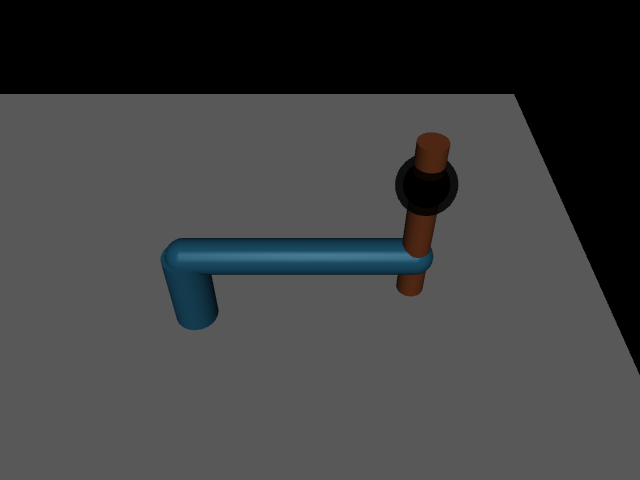

--------------------------------------------------
✅ Pose 2 PASSED


""

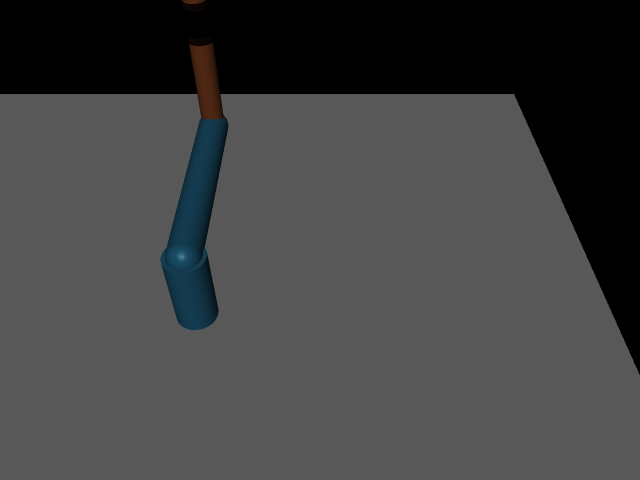

--------------------------------------------------
✅ Pose 3 PASSED


""

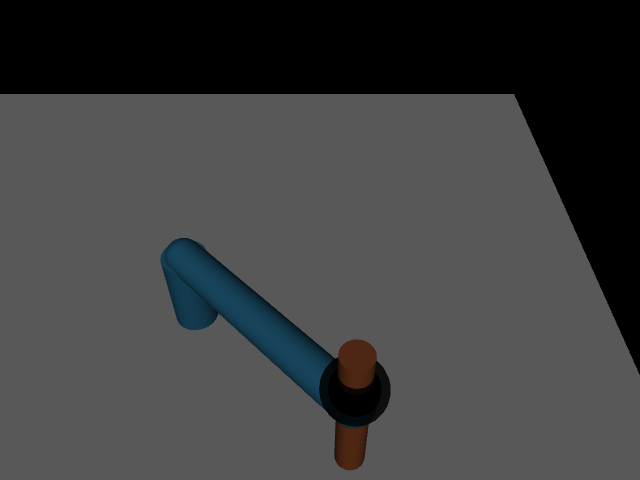

--------------------------------------------------
✅ Pose 4 PASSED


""

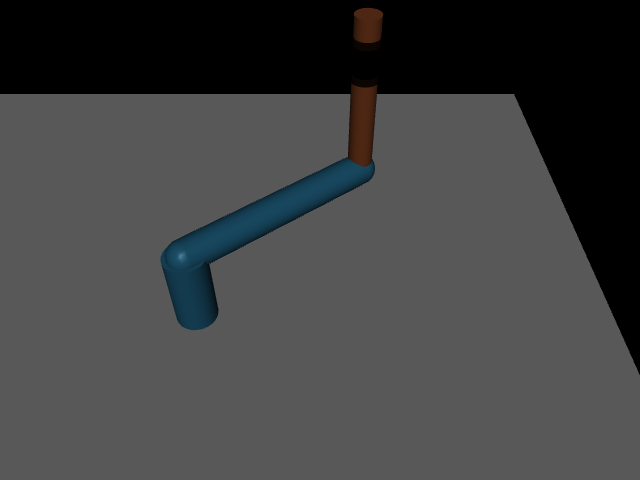

--------------------------------------------------

Final Score: 4/4 Poses Matched.



In [85]:
import mujoco
import numpy as np
import mediapy as media

def test_prismatic_joint():
    # 1. Define a custom 2-DOF (Revolute-Prismatic) robot using inline XML
    crane_xml = """
    <mujoco model="Cylindrical_Crane">
        <compiler angle="radian"/>
        <visual>
            <global fovy="45"/>
        </visual>
        <worldbody>
            <light pos="0 0 3" dir="0 0 -1"/>
            <geom type="plane" size="1 1 0.1" rgba="0.9 0.9 0.9 1"/>
            
            <!-- Link 1: Revolute Base -->
            <body name="link1" pos="0 0 0.2">
                <joint name="q1" type="hinge" axis="0 0 1"/>
                <!-- Visualizing the vertical pillar and horizontal boom -->
                <geom type="cylinder" fromto="0 0 -0.2 0 0 0" size="0.05" rgba="0.2 0.6 0.8 1"/>
                <geom type="capsule" fromto="0 0 0 0.5 0 0" size="0.04" rgba="0.2 0.6 0.8 1"/>
                
                <!-- Link 2: Prismatic Slider -->
                <body name="link2" pos="0.5 0 0">
                    <joint name="q2" type="slide" axis="0 0 1"/>
                    <!-- Visualizing the sliding piston -->
                    <geom type="cylinder" fromto="0 0 -0.1 0 0 0.3" size="0.03" rgba="0.8 0.4 0.2 1"/>
                    
                    <!-- End Effector Frame -->
                    <body name="ee" pos="0 0 0.2">
                        <site name="ee_site" pos="0 0 0" size="0.02" rgba="0 0 0 1"/>
                    </body>
                </body>
            </body>
        </worldbody>
    </mujoco>
    """

    # Load the inline model
    try:
        model = mujoco.MjModel.from_xml_string(crane_xml)
        data = mujoco.MjData(model)
    except Exception as e:
        print(f"Failed to load inline MuJoCo model: {e}")
        return

    # 2. Define the Standard DH Table for this custom robot
    # [theta_offset, d_offset, a, alpha]
    crane_dh = np.array([
        [0.0, 0.2, 0.5, 0.0],  # Joint 1: Revolute (Z-axis offset 0.2, X-axis length 0.5)
        [0.0, 0.2, 0.0, 0.0]   # Joint 2: Prismatic (Static Z offset 0.2 to reach EE)
    ])
    
    # Notice the second joint is 'P'
    joint_types = ['R', 'P']

    # 3. Test Cases [q1 (rad), q2 (m)]
    test_cases = [
        np.array([0.0, 0.0]),             # Home position
        np.array([np.pi / 2, 0.1]),       # Rotate 90 deg, slide UP 10cm
        np.array([-np.pi / 4, -0.15]),    # Rotate -45 deg, slide DOWN 15cm
        np.array([0.66, 0.1])            # Rotate 10.66 radians, slide UP 10cm
    ]

    ee_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "ee")

    # 4. Evaluation and Visualization
    print("--- Prismatic Joint Evaluation Summary ---\n")
    passed = 0
    failed = 0

    with mujoco.Renderer(model, height=480, width=640) as renderer:
        # Set a nice camera angle for the custom robot

        for i, q_test in enumerate(test_cases):
            # Update MuJoCo
            data.qpos[:] = q_test
            mujoco.mj_kinematics(model, data)
            mujoco_pos = data.xpos[ee_id].copy()

            # Calculate DH position
            T_ee, _ = forward_kinematics(q_test, crane_dh, joint_types)
            dh_pos = T_ee[:3, 3]

            # Verify the math
            if np.allclose(dh_pos, mujoco_pos, atol=1e-4):
                passed += 1
                print(f"✅ Pose {i+1} PASSED")
            else:
                failed += 1
                print(f"❌ Pose {i+1} FAILED")
                print(f"   DH Pos:     {np.round(dh_pos, 4)}")
                print(f"   MuJoCo Pos: {np.round(mujoco_pos, 4)}")

            renderer.update_scene(data)

            # --- ADD RED SPHERE (MuJoCo Ground Truth) ---
            if renderer.scene.ngeom < renderer.scene.maxgeom:
                geom = renderer.scene.geoms[renderer.scene.ngeom]
                mujoco.mjv_initGeom(
                    geom,
                    mujoco.mjtGeom.mjGEOM_SPHERE,
                    np.array([0.06, 0.0, 0.0]),                      
                    mujoco_pos,                                      
                    np.eye(3).flatten(),                             
                    np.array([1.0, 0.0, 0.0, 0.6], dtype=np.float32) 
                )
                renderer.scene.ngeom += 1

            # --- ADD YELLOW SPHERE (DH Algorithm) ---
            if renderer.scene.ngeom < renderer.scene.maxgeom:
                geom = renderer.scene.geoms[renderer.scene.ngeom]
                mujoco.mjv_initGeom(
                    geom,
                    mujoco.mjtGeom.mjGEOM_SPHERE,
                    np.array([0.045, 0.0, 0.0]),                     
                    dh_pos,                                          
                    np.eye(3).flatten(),                             
                    np.array([1.0, 1.0, 0.0, 0.9], dtype=np.float32) 
                )
                renderer.scene.ngeom += 1

            # Render and display
            media.show_image(renderer.render())
            print("-" * 50)

    print(f"\nFinal Score: {passed}/{passed+failed} Poses Matched.\n")

# Execute
if __name__ == "__main__":
    test_prismatic_joint()

# Task 2: Inverse Kinematics (IK) - 2 Points

Forward Kinematics answers: *"If I set my joints to these angles, where does my hand end up?"*
Inverse Kinematics (IK) answers the much harder robotics problem: *"I want my hand at this $(X, Y, Z)$ coordinate; what angles do my joints need to be?"*

In this exercise, you will implement the numerical version of inverse kinematics we mentioned in the lecture.

###  Numerical IK (The Iterative Approach)
For a 7-DOF robot, exact mathematical solutions are complex. Instead, we can use a numerical approach. We will calculate the **Jacobian Matrix** ($J$), which describes how a tiny change in each joint affects the end-effector's position. 
By inverting this matrix (using the Moore-Penrose Pseudo-Inverse $J^+$), we can calculate the exact joint steps needed to pull the arm toward the target, repeating this loop until the error is close to zero.

### Functions which will be helpful for you:
- np.linalg.pinv : Can compute the pseudo inverse of a matrix
- calculate_jacobian : Function given below which calculates for you an approximate jacobian of a function using scipy 


In [86]:
def calculate_jacobian(x, dh_table, joint_types):
    """
    Calculate the Jacobian assuming that x is a vector and f returns a trnasformation matrix.
    This function is given such that you have an easier time!
    Also note that we only compute the jacobian for the position here
    """
    f = lambda pos : forward_kinematics(pos, dh_table, joint_types)[0][:3, 3]
    J = scipy.optimize.approx_fprime(x, f, epsilon=1e-6)
    
    return J
    

In [87]:
import scipy

def numerical_ik_position(target_pos, q_init, dh_table, joint_types, max_iter=100, tol=1e-4):
    """
    Solves for joint angles to reach a target (X, Y, Z) position using the
    Jacobian Pseudo-Inverse method with finite differences.
    """
    q = q_init.copy()
    step_size = 0.3  # Damping factor to prevent wild swinging

    # Store the initial pose
    history = [q.copy()]

    for iteration in range(max_iter):

        #where the ee is now and how far off it is
        T, _ = forward_kinematics(q, dh_table, joint_types)
        error = target_pos - T[:3, 3]

        # Check if we are close enough - requires that you compute the error above!
        if np.linalg.norm(error) < tol:
            print(f"Numerical IK converged in {iteration} iterations.")
            return q, history
        
        #pull q toward the target along the pseudo inverse direction
        J = calculate_jacobian(q, dh_table, joint_types)
        dq = np.linalg.pinv(J) @ error
        q = q + step_size * dq

        
        # Save the current state to our history
        history.append(q.copy())
        
    print("Numerical IK reached max iterations without fully converging.")
    return q, history


### Task 2 Test case 1

In [88]:
import numpy as np

franka_dh = np.array([
        [0.0, 0.333, 0.0, -np.pi / 2],
        [0.0, 0.0, 0.0, np.pi / 2],
        [0.0, 0.316, 0.0825, np.pi / 2],
        [0.0, 0.0, -0.0825, -np.pi / 2],
        [0.0, 0.384, 0.0, np.pi / 2],
        [0.0, 0.0, 0.088, np.pi / 2],
        [0.0, 0.107, 0.0, 0.0],
    ])
joint_types = ['R'] * 7
print("--- Testing Numerical IK ---")
target_xyz = np.array([0.4, -0.2, 0.5])
# Start from the home pose, appended with 0 for the 8th static flange row
q_start = np.array([0.0, -np.pi/4, 0.0, -3*np.pi/4, 0.0, np.pi/2, np.pi/4])

q_sol_num, _ = numerical_ik_position(target_xyz, q_start, franka_dh, joint_types)

T_final, _ = forward_kinematics(q_sol_num, franka_dh, joint_types)
print(f"Target Pos: {target_xyz}")
print(f"Actual Pos: {np.round(T_final[:3, 3], 4)}")
print(f"Error:      {np.round(np.linalg.norm(target_xyz - T_final[:3, 3]), 5)} m\n")

--- Testing Numerical IK ---
Numerical IK converged in 22 iterations.
Target Pos: [ 0.4 -0.2  0.5]
Actual Pos: [ 0.4    -0.1999  0.5   ]
Error:      9e-05 m



# Task 2 Test Case 2: Visualizing Inverse Kinematics in MuJoCo

Now for the grand finale. Let's put your IK solver to work!

We have defined a list of 3D target coordinates. The code below will place a **green sphere** at each target location in the MuJoCo world. It will then use your `numerical_ik_position` function to calculate the necessary joint angles to reach that sphere, and smoothly animate the robot moving to the solved configuration.

If your IK solver is working correctly, the robot's end-effector (flange) will elegantly sweep through space and "boop" the center of each green sphere!


--- Running IK Solver and Generating Video ---

Solving for Target 1: [0.4 0.3 0.4]
Numerical IK converged in 23 iterations.

Solving for Target 2: [ 0.5 -0.3  0.6]
Numerical IK converged in 25 iterations.

Solving for Target 3: [0.3 0.  0.7]
Numerical IK converged in 24 iterations.

✅ Video generation complete! Displaying...


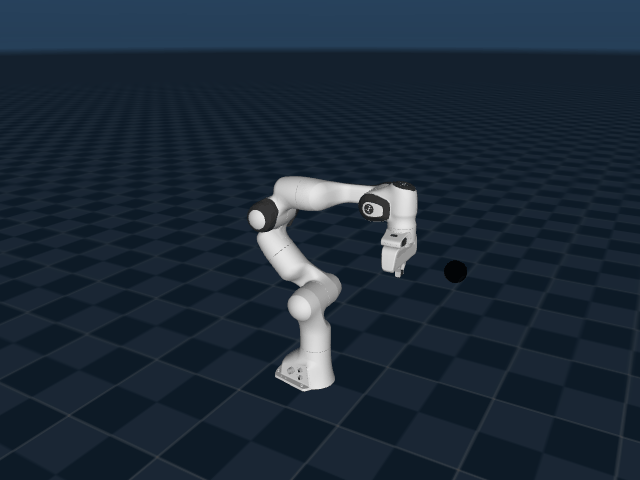

In [89]:
import mujoco
import numpy as np
import mediapy as media
#added these imports so the cell runs on its own
import io
from PIL import Image
from IPython.display import display, Image as IPImage


def visualize_ik_solver_steps():
    # 1. Load the MuJoCo model
    model_path = "mujoco_menagerie/franka_emika_panda/scene.xml"
    try:
        model = mujoco.MjModel.from_xml_path(model_path)
        data = mujoco.MjData(model)
    except Exception as e:
        print(f"Failed to load MuJoCo model: {e}")
        return

    # 2. Define a sequence of target (X, Y, Z) coordinates to reach
    targets = [
        np.array([0.4,  0.3, 0.4]),  # Forward-Left-Low
        np.array([0.5, -0.3, 0.6]),  # Forward-Right-High
        np.array([0.3,  0.0, 0.7]),  # Close-Center-Very High
    ]

    # Start from the home pose
    current_q = np.array([0.0, -np.pi/4, 0.0, -3*np.pi/4, 0.0, np.pi/2, np.pi/4])
    
    cam = mujoco.MjvCamera()
    mujoco.mjv_defaultFreeCamera(model, cam)
    cam.distance = 2.0
    cam.azimuth = 180.0
    cam.elevation = -15.0
    cam.lookat[:] = [0.0, 0.0, 0.4]

    framerate = 1
    frames = []

    # EXPLICIT OVERRIDE: Ensure all actuator control signals are zeroed out
    # so they don't fight our kinematic overrides if physics were ever enabled.
    if model.nu > 0:
        data.ctrl[:] = 0.0

    print("--- Running IK Solver and Generating Video ---")

    with mujoco.Renderer(model, height=480, width=640) as renderer:
        for i, target_pos in enumerate(targets):
            print(f"\nSolving for Target {i+1}: {target_pos}")
            
            # Get the LIST of all intermediate calculation steps
            _, q_history = numerical_ik_position(
                target_pos, 
                current_q, 
                franka_dh, 
                joint_types
            )
            
            # Animate the actual solver steps instead of an artificial interpolation
            for step_q in q_history:
                
                # Apply the solver's intermediate joint angles to MuJoCo
                data.qpos[:7] = step_q[:7]
                mujoco.mj_kinematics(model, data)
                renderer.update_scene(data)

                # Add a GREEN SPHERE marker at the target (X, Y, Z) position
                if renderer.scene.ngeom < renderer.scene.maxgeom:
                    geom = renderer.scene.geoms[renderer.scene.ngeom]
                    mujoco.mjv_initGeom(
                        geom,
                        mujoco.mjtGeom.mjGEOM_SPHERE,
                        np.array([0.04, 0.0, 0.0]),                      # 4cm radius
                        target_pos,                                      # Target position
                        np.eye(3).flatten(),                             
                        np.array([0.0, 1.0, 0.0, 0.6], dtype=np.float32) # Translucent Green
                    )
                    renderer.scene.ngeom += 1

                frames.append(renderer.render())
                
            # Update current pose for the next target
            current_q = q_history[-1].copy()
            
            # Hold at the target for half a second before moving to the next
            for _ in range(int(framerate * 0.5)):
                frames.append(renderer.render())

    print("\n✅ Video generation complete! Displaying...")
    # media.show_video(frames, fps=framerate)
    pil_images = [Image.fromarray(frame) for frame in frames]
    
    # Save frames into an in-memory byte buffer as an animated GIF
    buffer = io.BytesIO()
    pil_images[0].save(
        buffer,
        format='GIF',
        save_all=True,
        append_images=pil_images[1:],
        duration=int(500 / framerate), # duration per frame in milliseconds
        loop=0
    )
    buffer.seek(0)

    
    # Display the GIF inside the Jupyter notebook
    display(IPImage(data=buffer.read(), format='gif'))

if __name__ == "__main__":
    # Execute the visualization
    visualize_ik_solver_steps()